# Time-Series AIME for Emprical Dynamic Model

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q pyEDM aime-xai numpy pandas matplotlib
!pip install -q /content/drive/MyDrive/Colab\ Notebooks/Research/EDM/package/dist/tsaime-0.1.0.tar.gz

  Preparing metadata (setup.py) ... done


In [5]:
from tsaime import RollingAIME, RollingAIMEConfig

In [6]:
import io, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- UCI Bike Sharing (day) をDL → Date/Time 整形 ----
UCI_ZIP = "https://archive.ics.uci.edu/static/public/275/bike%2Bsharing%2Bdataset.zip"

def load_bike_sharing_day():
    with urllib.request.urlopen(UCI_ZIP) as resp:
        zdata = resp.read()
    with zipfile.ZipFile(io.BytesIO(zdata)) as zf:
        with zf.open("day.csv") as f:
            df = pd.read_csv(f, parse_dates=["dteday"])
    df = df.rename(columns={"dteday":"Date"})
    df = df[["Date","cnt","temp","hum","windspeed"]].sort_values("Date").reset_index(drop=True)
    date0 = df["Date"].iloc[0]
    df["Time"] = (df["Date"] - date0).dt.days + 1  # 1..N（pyEDM向け）
    # pyEDMはTimeが先頭にあると扱いやすい
    df = df[["Time","Date","cnt","temp","hum","windspeed"]]
    return df, date0

def to_date(int_time, date0):
    return pd.to_datetime(date0) + pd.to_timedelta(int_time - 1, unit="D")

df, date0 = load_bike_sharing_day()
print("df:", df.shape, "\n", df.head())

df: (731, 6) 
    Time       Date   cnt      temp       hum  windspeed
0     1 2011-01-01   985  0.344167  0.805833   0.160446
1     2 2011-01-02   801  0.363478  0.696087   0.248539
2     3 2011-01-03  1349  0.196364  0.437273   0.248309
3     4 2011-01-04  1562  0.200000  0.590435   0.160296
4     5 2011-01-05  1600  0.226957  0.436957   0.186900


best_E = 4
theta_star = 4.0
Simplex: rho=0.707, MAE=2559.9, RMSE=1405.5
S-Map  : rho=0.747, MAE=2299.5, RMSE=1298.6
CCM head:
    LibSize  cnt::temp  temp::cnt
0       10   0.615221   0.547695
1       20   0.656254   0.568315
2       30   0.666938   0.577841
3       40   0.677759   0.585817
4       50   0.683143   0.585616


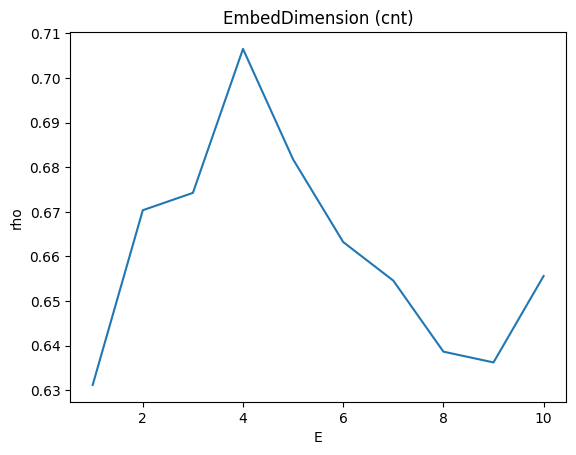

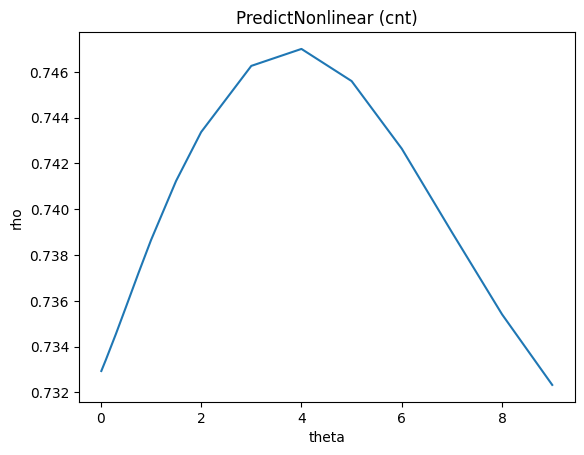

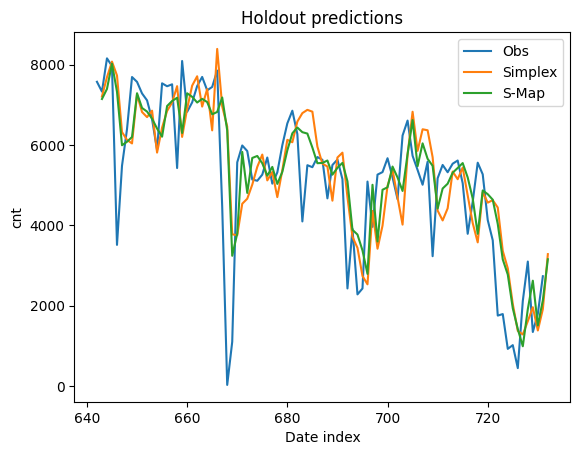

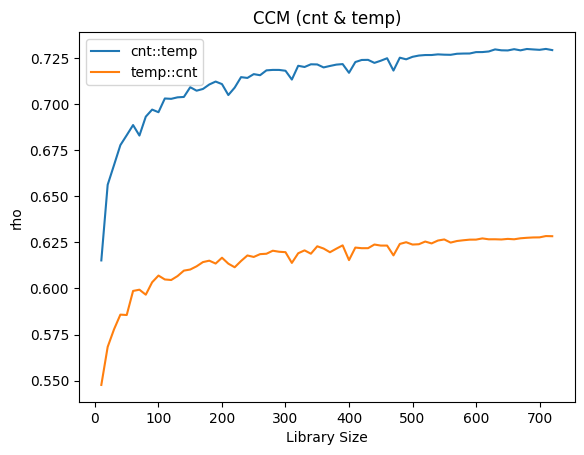

In [7]:
import pyEDM as ed

N = len(df); holdout = 90
lib  = f"1 {N - holdout}"
pred = f"{N - holdout + 1} {N}"

# 1) Embedded Dimension Exploration
ED = ed.EmbedDimension(dataFrame=df[["Time","cnt"]], columns="cnt", target="cnt",
                       lib=lib, pred=pred, maxE=10, showPlot=False)
best_E = int(ED.loc[ED["rho"].idxmax(), "E"])
print("best_E =", best_E)

# 2) Search for θ (nonlinearity)
PN = ed.PredictNonlinear(dataFrame=df[["Time","cnt"]], columns="cnt", target="cnt",
                         lib=lib, pred=pred, E=best_E, showPlot=False)
theta_star = float(PN.loc[PN["rho"].idxmax(), "theta"])
print("theta_star =", theta_star)

# 3) Simplex / S-Map Accuracy
sx = ed.Simplex(dataFrame=df[["Time","cnt"]], columns="cnt", target="cnt",
                lib=lib, pred=pred, E=best_E, showPlot=False)
sx_err = ed.ComputeError(sx["Observations"], sx["Predictions"])
print(f"Simplex: rho={sx_err['rho']:.3f}, MAE={sx_err['MAE']:.1f}, RMSE={sx_err['RMSE']:.1f}")

sm = ed.SMap(dataFrame=df[["Time","cnt"]], columns="cnt", target="cnt",
             lib=lib, pred=pred, E=best_E, theta=theta_star, showPlot=False)
sm_err = ed.ComputeError(sm["predictions"]["Observations"], sm["predictions"]["Predictions"])
print(f"S-Map  : rho={sm_err['rho']:.3f}, MAE={sm_err['MAE']:.1f}, RMSE={sm_err['RMSE']:.1f}")

# 4) CCM (Directionality from Temperature to Demand)
ccm = ed.CCM(dataFrame=df[["Time","cnt","temp"]],
             columns="cnt", target="temp", E=best_E,
             libSizes=f"10 {N-5} 10", sample=100, seed=42, showPlot=False)
if ccm.shape[1] == 3:
    ccm.columns = ["LibSize","cnt::temp","temp::cnt"]
print("CCM head:\n", ccm.head())

# Plot (Simplified)
plt.figure(); plt.plot(ED["E"], ED["rho"]); plt.title("EmbedDimension (cnt)"); plt.xlabel("E"); plt.ylabel("rho")
plt.figure(); plt.plot(PN["theta"], PN["rho"]); plt.title("PredictNonlinear (cnt)"); plt.xlabel("theta"); plt.ylabel("rho")
plt.figure();
plt.plot(sx["Time"], sx["Observations"], label="Obs")
plt.plot(sx["Time"], sx["Predictions"], label="Simplex")
plt.plot(sm["predictions"]["Time"], sm["predictions"]["Predictions"], label="S-Map")
plt.legend(); plt.title("Holdout predictions"); plt.xlabel("Date index"); plt.ylabel("cnt")
plt.figure();
plt.plot(ccm["LibSize"], ccm["cnt::temp"], label="cnt::temp")
plt.plot(ccm["LibSize"], ccm["temp::cnt"], label="temp::cnt")
plt.legend(); plt.title("CCM (cnt & temp)"); plt.xlabel("Library Size"); plt.ylabel("rho")
plt.show()

shapes: (642, 4) (642, 4) (642, 4)


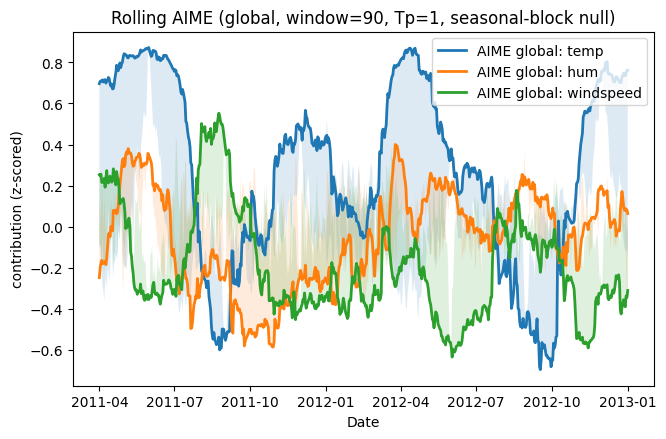

In [10]:
from tsaime import RollingAIME, RollingAIMEConfig

# ts-AIME Settings:
#  - window=90, Tp=1 (1 day ahead)
#  - Seasonal block nullification: Requires a Date column in df to use "season" (DJF/MAM/JJA/SON)
#  - R=400 (replacement count; set to 1000 or higher for reporting ◎)
cfg = RollingAIMEConfig(
    window=90, tp=1,
    R=400, seed=0,
    block_null="season", date_column="Date",
    pre_normalize_y=True
)
tsa = RollingAIME(cfg)

# ts-AIME execution (multivariate S-Map: embedded=True)
#feats = ["cnt","temp","hum","windspeed"]   # Column on the X(t) side (state embedding including cnt)
feats = ["temp","hum","windspeed"]
G_ts, L_ts, env_lo, env_hi, pvals = tsa.fit_with_pyEDM(
    df=df, columns=feats, target="cnt",
    E=best_E, theta=theta_star, embedded=True
)

print("shapes:", G_ts.shape, L_ts.shape, None if env_lo is None else env_lo.shape)

# Local Contribution (End of Window)
plt.figure(figsize=(7.5,4.6))
for f in ["temp","hum","windspeed"]:
    if env_lo is not None:
        plt.fill_between(
            to_date(env_lo["Time"], date0), env_lo[f], env_hi[f],
            alpha=0.15, zorder=1
        )
    plt.plot(
        to_date(G_ts["Time"], date0), G_ts[f],
        label=f"AIME global: {f}", lw=2, zorder=3
    )
plt.legend(); plt.title("Rolling AIME (global, window=90, Tp=1, seasonal-block null)")
plt.xlabel("Date"); plt.ylabel("contribution (z-scored)")
plt.show()

In [15]:
# FDR(BH) and continuous interval extraction
def fdr_bh(p, alpha=0.05):
    p = np.asarray(p, float); n=len(p)
    order = np.argsort(p); rank = np.arange(1, n+1)
    thresh = alpha * rank / n
    passed = p[order] <= thresh
    k = passed.nonzero()[0].max()+1 if passed.any() else 0
    crit = thresh[k-1] if k>0 else 0
    return p <= crit

def contiguous_segments(timestamps, is_sig):
    segs=[]; start=None; prev=None
    for t,s in zip(timestamps, is_sig):
        if s and start is None:
            start = t
        elif not s and start is not None:
            segs.append((start, prev)); start=None
        prev=t
    if start is not None: segs.append((start, prev))
    return segs

# Significance interval of temp
if pvals is not None:
    sig_temp = fdr_bh(pvals["temp"].values, alpha=0.05)
    segs = contiguous_segments(to_date(G_ts["Time"], date0), sig_temp)
    print("temp 有意区間（FDR<0.05）:")
    for s,e in segs:
        print(s.date(), "→", e.date())

    out = pd.DataFrame({
        "Date": to_date(G_ts["Time"], date0),
        "global_temp": G_ts["temp"].values,
        "pval_temp": pvals["temp"].values,
        "sig_temp": sig_temp.astype(int)
    })
    out.to_csv("tsaime_temp_daily.csv", index=False)
    print("Saved:", "tsaime_temp_daily.csv")
else:
    print("pvals is None (R=0 の場合は有意判定なし).")

temp 有意区間（FDR<0.05）:
2011-04-01 → 2011-07-20
2011-07-22 → 2011-07-23
2011-08-03 → 2011-09-01
2011-09-03 → 2011-09-18
2011-09-20 → 2011-09-20
2011-09-23 → 2011-09-24
2011-10-14 → 2011-10-14
2011-10-16 → 2011-10-21
2011-10-27 → 2012-01-01
2012-01-04 → 2012-01-06
2012-01-10 → 2012-01-10
2012-02-29 → 2012-03-01
2012-03-05 → 2012-06-01
2012-06-04 → 2012-07-22
2012-07-25 → 2012-07-26
2012-07-29 → 2012-08-04
2012-08-06 → 2012-08-08
2012-08-12 → 2012-10-07
2012-10-11 → 2012-10-14
2012-10-18 → 2012-10-18
2012-10-20 → 2012-10-22
2012-10-30 → 2012-10-31
2012-11-03 → 2012-11-28
2012-11-30 → 2013-01-01
Saved: tsaime_temp_daily.csv


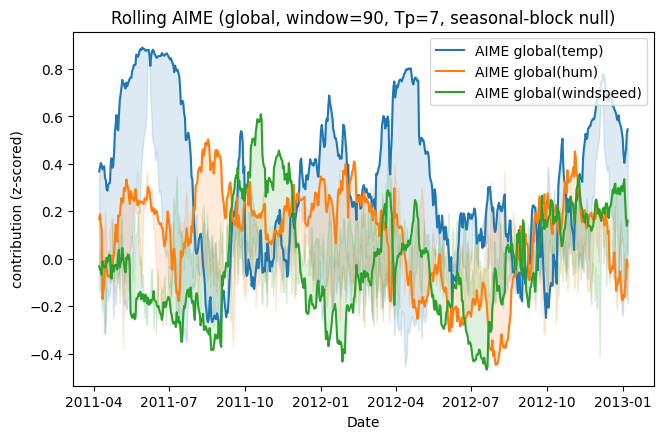

In [16]:
cfg7 = RollingAIMEConfig(
    window=90, tp=7,
    R=400, seed=0,
    block_null="season", date_column="Date",
    pre_normalize_y=True
)
tsa7 = RollingAIME(cfg7)
G7, L7, lo7, hi7, pv7 = tsa7.fit_with_pyEDM(
    df=df, columns=feats, target="cnt",
    E=best_E, theta=theta_star, embedded=True
)

plt.figure(figsize=(7.5,4.6))
for f in ["temp","hum","windspeed"]:
    (ln,) = plt.plot(to_date(G7["Time"], date0), G7[f], label=f"AIME global({f})")
    c = ln.get_color()
    if lo7 is not None:
        plt.fill_between(to_date(lo7["Time"], date0), lo7[f], hi7[f], color=c, alpha=0.15)
plt.legend(); plt.title("Rolling AIME (global, window=90, Tp=7, seasonal-block null)")
plt.xlabel("Date"); plt.ylabel("contribution (z-scored)")
plt.show()